In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import mnist

In [3]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()
print("Training images shape:",X_train.shape)
print("Testing images shape:",X_test.shape)
print("Training labels shape:",y_train.shape)
print("Testing labels shape:",y_test.shape)

Training images shape: (60000, 28, 28)
Testing images shape: (10000, 28, 28)
Training labels shape: (60000,)
Testing labels shape: (10000,)


In [4]:
print("Unique classes:",np.unique(y_train))
print("\nClass distribution in training set:")
unique,counts=np.unique(y_train,return_counts=True)
for digit,count in zip(unique,counts):
    print(f"  Digit {digit}: {count} samples")

Unique classes: [0 1 2 3 4 5 6 7 8 9]

Class distribution in training set:
  Digit 0: 5923 samples
  Digit 1: 6742 samples
  Digit 2: 5958 samples
  Digit 3: 6131 samples
  Digit 4: 5842 samples
  Digit 5: 5421 samples
  Digit 6: 5918 samples
  Digit 7: 6265 samples
  Digit 8: 5851 samples
  Digit 9: 5949 samples


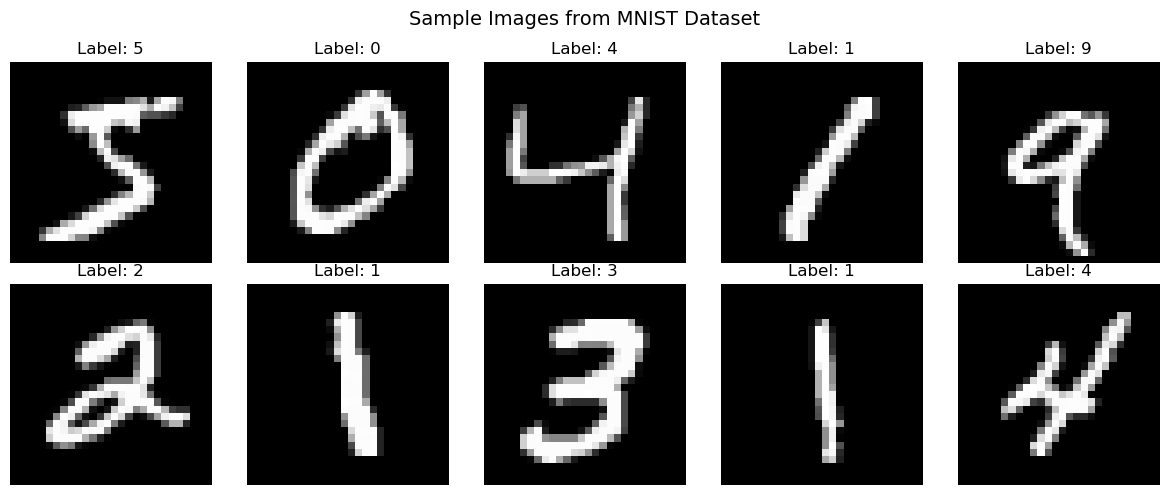

In [5]:
fig,axes=plt.subplots(2,5,figsize=(12,5))
fig.suptitle("Sample Images from MNIST Dataset", fontsize=14)

for i,ax in enumerate(axes.flat):
    ax.imshow(X_train[i],cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')

plt.tight_layout()
plt.savefig('../images/sample_digits.png')
plt.show()

In [6]:
X_train=X_train/255.0
X_test=X_test/255.0

print("Pixel value range after normalization:")
print("Min:",X_train.min(),"Max:",X_train.max())

Pixel value range after normalization:
Min: 0.0 Max: 1.0


In [7]:
X_train_flat=X_train.reshape(X_train.shape[0],-1)
X_test_flat=X_test.reshape(X_test.shape[0],-1)

print("Before flattening:",X_train.shape)
print("After flattening:",X_train_flat.shape)

Before flattening: (60000, 28, 28)
After flattening: (60000, 784)


In [8]:
from tensorflow.keras.utils import to_categorical

y_train_encoded=to_categorical(y_train,num_classes=10)
y_test_encoded=to_categorical(y_test,num_classes=10)

print("Before encoding:",y_train[0])
print("After encoding:",y_train_encoded[0])

Before encoding: 5
After encoding: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model=Sequential([
    Dense(128,activation='relu',input_shape=(784,)),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

model.summary()

C:\Users\Adrija\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [11]:
history=model.fit(
    X_train_flat,y_train_encoded,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9229 - loss: 0.2632 - val_accuracy: 0.9569 - val_loss: 0.1410
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9656 - loss: 0.1123 - val_accuracy: 0.9641 - val_loss: 0.1139
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9771 - loss: 0.0745 - val_accuracy: 0.9617 - val_loss: 0.1238
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9813 - loss: 0.0569 - val_accuracy: 0.9701 - val_loss: 0.0997
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9852 - loss: 0.0449 - val_accuracy: 0.9706 - val_loss: 0.1060
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9883 - loss: 0.0352 - val_accuracy: 0.9736 - val_loss: 0.0999
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9899 - loss: 0.0302 - val_accuracy: 0.9716 - val_loss: 0.1010
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9916 -

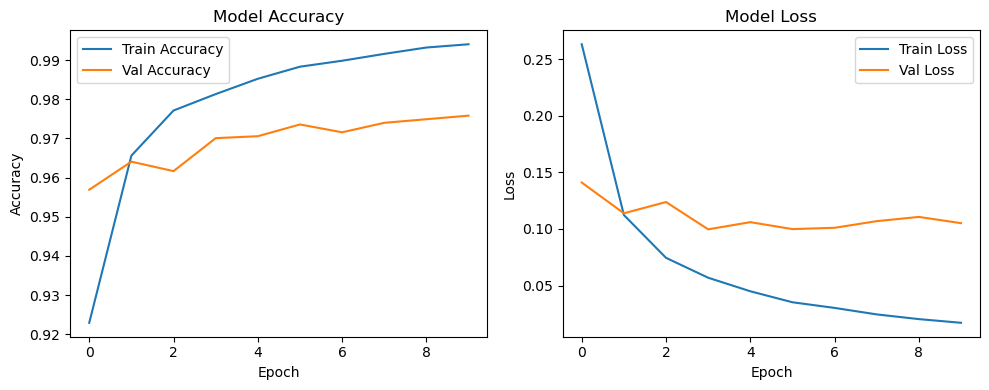

In [12]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('../images/training_curves.png')